In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Final Year Project\emotional-wellbeing-system\.venv\Scripts\python.exe
3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]


# Dataset Exploration

## Purpose

This notebook examines the emotion-text dataset before model development.
The analysis will investigate its structure, data types, missing values,
duplicate records, emotion labels, class distribution, and text-length
characteristics.

The results will guide preprocessing, model selection, evaluation, and the
final emotion-label decision.

In [13]:
import sys
import pandas as pd

print(sys.executable)
print(pd.__version__)

/home/presi/venvs/emotional-wellbeing/bin/python
3.0.5


In [14]:
import sys
import pandas as pd
import numpy as np
import matplotlib

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python executable: /home/presi/venvs/emotional-wellbeing/bin/python
Python version: 3.14.4 (main, Jun 18 2026, 14:25:02) [GCC 15.2.0]
Pandas version: 3.0.5
NumPy version: 2.5.1
Matplotlib version: 3.11.1


In [15]:
from pathlib import Path

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parents[1]
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

RAW_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

print(f"Current directory: {CURRENT_DIRECTORY}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")

Current directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/notebooks
Project root: /mnt/c/Final Year Project/emotional-wellbeing-system
Raw data directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/data/raw
Processed data directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/data/processed


In [16]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", "split")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [17]:
print(dataset["train"].features)
print(dataset["train"][0])

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}
{'text': 'i didnt feel humiliated', 'label': 0}


In [18]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


In [19]:
train_df.to_csv(RAW_DATA_DIR / "emotion_train.csv", index=False)
validation_df.to_csv(RAW_DATA_DIR / "emotion_validation.csv", index=False)
test_df.to_csv(RAW_DATA_DIR / "emotion_test.csv", index=False)

print("Raw dataset files saved successfully.")

Raw dataset files saved successfully.


In [20]:
dataset
train_df
validation_df
test_df
RAW_DATA_DIR
PROCESSED_DATA_DIR

PosixPath('/mnt/c/Final Year Project/emotional-wellbeing-system/ml/data/processed')

In [21]:
LABEL_NAMES = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}

## Initial Data Quality Assessment

This section examines the dataset for missing values, empty text, duplicate
records, invalid labels, class imbalance, and unusual text lengths.

These checks are completed before preprocessing and model training because
poor-quality data may reduce model reliability or create misleading
evaluation results.

In [22]:
def display_basic_information(name: str, dataframe: pd.DataFrame) -> None:
    """Display the structure and sample records of one dataset split."""

    print(f"\n{name.upper()} SPLIT")
    print("=" * 50)

    print("Shape:", dataframe.shape)
    print("Columns:", list(dataframe.columns))

    print("\nData types:")
    print(dataframe.dtypes)

    print("\nFirst five records:")
    display(dataframe.head())


display_basic_information("train", train_df)
display_basic_information("validation", validation_df)
display_basic_information("test", test_df)


TRAIN SPLIT
Shape: (16000, 2)
Columns: ['text', 'label']

Data types:
text       str
label    int64
dtype: object

First five records:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3



VALIDATION SPLIT
Shape: (2000, 2)
Columns: ['text', 'label']

Data types:
text       str
label    int64
dtype: object

First five records:


,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1



TEST SPLIT
Shape: (2000, 2)
Columns: ['text', 'label']

Data types:
text       str
label    int64
dtype: object

First five records:


,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0


### Missing and Empty Value Checks

Missing text or labels cannot be used reliably for supervised model training.
Whitespace-only text is also treated as empty input.

In [23]:
def inspect_missing_values(name: str, dataframe: pd.DataFrame) -> pd.Series:
    """Return and display missing and empty-value statistics."""

    missing_text = dataframe["text"].isna().sum()
    missing_labels = dataframe["label"].isna().sum()

    empty_text = (
        dataframe["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    results = pd.Series({
        "rows": len(dataframe),
        "missing_text": missing_text,
        "missing_labels": missing_labels,
        "empty_or_whitespace_text": empty_text,
    })

    print(f"\n{name.upper()} SPLIT")
    print(results)

    return results


train_missing = inspect_missing_values("train", train_df)
validation_missing = inspect_missing_values("validation", validation_df)
test_missing = inspect_missing_values("test", test_df)


TRAIN SPLIT
rows                        16000
missing_text                    0
missing_labels                  0
empty_or_whitespace_text        0
dtype: int64

VALIDATION SPLIT
rows                        2000
missing_text                   0
missing_labels                 0
empty_or_whitespace_text       0
dtype: int64

TEST SPLIT
rows                        2000
missing_text                   0
missing_labels                 0
empty_or_whitespace_text       0
dtype: int64


In [24]:
VALID_LABELS = set(LABEL_NAMES.keys())


def inspect_labels(name: str, dataframe: pd.DataFrame) -> None:
    """Display unique labels and count labels outside the valid range."""

    unique_labels = sorted(dataframe["label"].dropna().unique().tolist())

    invalid_mask = ~dataframe["label"].isin(VALID_LABELS)
    invalid_count = invalid_mask.sum()

    print(f"\n{name.upper()} SPLIT")
    print("Unique labels:", unique_labels)
    print("Invalid labels:", invalid_count)

    if invalid_count > 0:
        display(dataframe.loc[invalid_mask].head())


inspect_labels("train", train_df)
inspect_labels("validation", validation_df)
inspect_labels("test", test_df)


TRAIN SPLIT
Unique labels: [0, 1, 2, 3, 4, 5]
Invalid labels: 0

VALIDATION SPLIT
Unique labels: [0, 1, 2, 3, 4, 5]
Invalid labels: 0

TEST SPLIT
Unique labels: [0, 1, 2, 3, 4, 5]
Invalid labels: 0


### Duplicate Record Checks

Duplicate examples can cause a model to overlearn repeated patterns.
Duplicates may also make evaluation results appear stronger than they truly
are if the same text appears multiple times.

In [25]:
def inspect_duplicates(name: str, dataframe: pd.DataFrame) -> int:
    """Display duplicate-row statistics for one split."""

    duplicate_count = dataframe.duplicated().sum()

    duplicate_text_count = dataframe.duplicated(
        subset=["text"],
        keep=False,
    ).sum()

    print(f"\n{name.upper()} SPLIT")
    print("Exact duplicate rows:", duplicate_count)
    print("Rows sharing duplicate text:", duplicate_text_count)

    if duplicate_count > 0:
        print("\nExample exact duplicates:")
        display(
            dataframe.loc[dataframe.duplicated(keep=False)]
            .sort_values("text")
            .head(10)
        )

    return duplicate_count


train_duplicate_count = inspect_duplicates("train", train_df)
validation_duplicate_count = inspect_duplicates(
    "validation",
    validation_df,
)
test_duplicate_count = inspect_duplicates("test", test_df)


TRAIN SPLIT
Exact duplicate rows: 1
Rows sharing duplicate text: 62

Example exact duplicates:


,text,label
4975,i feel more adventurous willing to take risks ...,1
13846,i feel more adventurous willing to take risks ...,1



VALIDATION SPLIT
Exact duplicate rows: 0
Rows sharing duplicate text: 4

TEST SPLIT
Exact duplicate rows: 0
Rows sharing duplicate text: 0


In [26]:
def find_conflicting_labels(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Find text values that have been assigned more than one emotion label.
    """

    label_counts_per_text = (
        dataframe.groupby("text")["label"]
        .nunique()
        .reset_index(name="unique_label_count")
    )

    conflicting_texts = label_counts_per_text[
        label_counts_per_text["unique_label_count"] > 1
    ]

    if conflicting_texts.empty:
        return pd.DataFrame(
            columns=["text", "label", "emotion"]
        )

    conflicts = dataframe.merge(
        conflicting_texts[["text"]],
        on="text",
        how="inner",
    )

    conflicts = conflicts.copy()
    conflicts["emotion"] = conflicts["label"].map(LABEL_NAMES)

    return conflicts.sort_values(["text", "label"])


train_conflicts = find_conflicting_labels(train_df)

print("Training texts with conflicting labels:", train_conflicts["text"].nunique())
display(train_conflicts.head(20))

Training texts with conflicting labels: 30


,text,label,emotion
6,i am not amazing or great at photography but i...,1,joy
24,i am not amazing or great at photography but i...,2,love
58,i began to feel accepted by gaia on her own terms,1,joy
11,i began to feel accepted by gaia on her own terms,2,love
57,i bet taylor swift basks in the knowledge that...,3,anger
27,i bet taylor swift basks in the knowledge that...,4,fear
47,i cant escape the tears of sadness and just tr...,1,joy
40,i cant escape the tears of sadness and just tr...,2,love
49,i could feel myself hit this strange foggy wall,4,fear
52,i could feel myself hit this strange foggy wall,5,surprise


### Cross-Split Data Leakage Check

The same text should ideally not appear in both training and evaluation data.
If a training example also appears in validation or test data, evaluation
performance may be artificially inflated.

In [27]:
train_texts = set(train_df["text"].astype(str))
validation_texts = set(validation_df["text"].astype(str))
test_texts = set(test_df["text"].astype(str))

train_validation_overlap = train_texts.intersection(validation_texts)
train_test_overlap = train_texts.intersection(test_texts)
validation_test_overlap = validation_texts.intersection(test_texts)

print(
    "Train-validation overlapping texts:",
    len(train_validation_overlap),
)

print(
    "Train-test overlapping texts:",
    len(train_test_overlap),
)

print(
    "Validation-test overlapping texts:",
    len(validation_test_overlap),
)

Train-validation overlapping texts: 5
Train-test overlapping texts: 11
Validation-test overlapping texts: 3


In [28]:
for dataframe in [train_df, validation_df, test_df]:
    dataframe["emotion"] = dataframe["label"].map(LABEL_NAMES)

display(train_df.head())

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Class Distribution

Class distribution shows how many examples are available for each emotion.
Large differences between classes can cause the model to favour categories
with more training examples.

In [29]:
def calculate_class_distribution(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """Return label counts and percentages."""

    counts = dataframe["emotion"].value_counts()

    percentages = (
        dataframe["emotion"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    distribution = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
    })

    return distribution.reindex(LABEL_NAMES.values())


train_distribution = calculate_class_distribution(train_df)
validation_distribution = calculate_class_distribution(validation_df)
test_distribution = calculate_class_distribution(test_df)

print("Training distribution")
display(train_distribution)

print("Validation distribution")
display(validation_distribution)

print("Test distribution")
display(test_distribution)

Training distribution


,count,percentage
emotion,,
sadness,4666,29.16
joy,5362,33.51
love,1304,8.15
anger,2159,13.49
fear,1937,12.11
surprise,572,3.58


Validation distribution


,count,percentage
emotion,,
sadness,550,27.50
joy,704,35.20
love,178,8.90
anger,275,13.75
fear,212,10.60
surprise,81,4.05


Test distribution


,count,percentage
emotion,,
sadness,581,29.05
joy,695,34.75
love,159,7.95
anger,275,13.75
fear,224,11.20
surprise,66,3.30


In [30]:
print("hello")

hello


In [31]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: /home/presi/venvs/emotional-wellbeing/bin/python
Pandas: 3.0.5
NumPy: 2.5.1
Scikit-learn: 1.9.0
Matplotlib: 3.11.1


## Initial Data Quality Assessment

The dataset is examined for missing values, empty text, invalid labels,
duplicate records, class imbalance, cross-split overlap, and unusual text
lengths before preprocessing and model training.

In [32]:
def inspect_missing_values(name, dataframe):
    missing_text = dataframe["text"].isna().sum()
    missing_labels = dataframe["label"].isna().sum()

    empty_text = (
        dataframe["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"\n{name.upper()}")
    print("Rows:", len(dataframe))
    print("Missing text:", missing_text)
    print("Missing labels:", missing_labels)
    print("Empty text:", empty_text)


inspect_missing_values("train", train_df)
inspect_missing_values("validation", validation_df)
inspect_missing_values("test", test_df)


TRAIN
Rows: 16000
Missing text: 0
Missing labels: 0
Empty text: 0

VALIDATION
Rows: 2000
Missing text: 0
Missing labels: 0
Empty text: 0

TEST
Rows: 2000
Missing text: 0
Missing labels: 0
Empty text: 0


In [33]:
VALID_LABELS = set(LABEL_NAMES.keys())


def inspect_labels(name, dataframe):
    unique_labels = sorted(dataframe["label"].dropna().unique().tolist())
    invalid_count = (~dataframe["label"].isin(VALID_LABELS)).sum()

    print(f"\n{name.upper()}")
    print("Unique labels:", unique_labels)
    print("Invalid labels:", invalid_count)


inspect_labels("train", train_df)
inspect_labels("validation", validation_df)
inspect_labels("test", test_df)


TRAIN
Unique labels: [0, 1, 2, 3, 4, 5]
Invalid labels: 0

VALIDATION
Unique labels: [0, 1, 2, 3, 4, 5]
Invalid labels: 0

TEST
Unique labels: [0, 1, 2, 3, 4, 5]
Invalid labels: 0


In [34]:
def inspect_duplicates(name, dataframe):
    exact_duplicates = dataframe.duplicated().sum()

    duplicate_text_rows = dataframe.duplicated(
        subset=["text"],
        keep=False
    ).sum()

    print(f"\n{name.upper()}")
    print("Exact duplicate rows:", exact_duplicates)
    print("Rows sharing duplicate text:", duplicate_text_rows)


inspect_duplicates("train", train_df)
inspect_duplicates("validation", validation_df)
inspect_duplicates("test", test_df)


TRAIN
Exact duplicate rows: 1
Rows sharing duplicate text: 62

VALIDATION
Exact duplicate rows: 0
Rows sharing duplicate text: 4

TEST
Exact duplicate rows: 0
Rows sharing duplicate text: 0


In [35]:
def find_conflicting_labels(dataframe):
    label_counts = (
        dataframe.groupby("text")["label"]
        .nunique()
        .reset_index(name="label_count")
    )

    conflicting_text = label_counts[
        label_counts["label_count"] > 1
    ]

    return dataframe.merge(
        conflicting_text[["text"]],
        on="text",
        how="inner"
    )


train_conflicts = find_conflicting_labels(train_df)

print(
    "Training texts with conflicting labels:",
    train_conflicts["text"].nunique()
)

display(train_conflicts.head(20))

Training texts with conflicting labels: 30


,text,label,emotion
0,i tend to stop breathing when i m feeling stre...,0,sadness
1,i feel on the verge of tears from weariness i ...,2,love
2,i was intensely conscious of how much cash i h...,3,anger
3,i still feel completely accepted,1,joy
4,im still not sure why reilly feels the need to...,4,fear
5,i shy away from songs that talk about how i fe...,2,love
6,i am not amazing or great at photography but i...,1,joy
7,i still feel a craving for sweet food,1,joy
8,i often find myself feeling assaulted by a mul...,4,fear
9,i had to choose the sleek and smoother feel of...,2,love


In [36]:
train_texts = set(train_df["text"].astype(str))
validation_texts = set(validation_df["text"].astype(str))
test_texts = set(test_df["text"].astype(str))

train_validation_overlap = train_texts & validation_texts
train_test_overlap = train_texts & test_texts
validation_test_overlap = validation_texts & test_texts

print(
    "Train-validation overlaps:",
    len(train_validation_overlap)
)

print(
    "Train-test overlaps:",
    len(train_test_overlap)
)

print(
    "Validation-test overlaps:",
    len(validation_test_overlap)
)

Train-validation overlaps: 5
Train-test overlaps: 11
Validation-test overlaps: 3


In [37]:
for dataframe in [train_df, validation_df, test_df]:
    dataframe["emotion"] = dataframe["label"].map(LABEL_NAMES)

display(train_df.head())

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [38]:
def calculate_class_distribution(dataframe):
    counts = dataframe["emotion"].value_counts()

    percentages = (
        dataframe["emotion"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    distribution = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
    })

    return distribution.reindex(LABEL_NAMES.values())


train_distribution = calculate_class_distribution(train_df)
validation_distribution = calculate_class_distribution(validation_df)
test_distribution = calculate_class_distribution(test_df)

display(train_distribution)

,count,percentage
emotion,,
sadness,4666,29.16
joy,5362,33.51
love,1304,8.15
anger,2159,13.49
fear,1937,12.11
surprise,572,3.58


In [39]:
class_distribution_comparison = pd.DataFrame({
    "train": train_df["emotion"].value_counts(),
    "validation": validation_df["emotion"].value_counts(),
    "test": test_df["emotion"].value_counts(),
}).reindex(LABEL_NAMES.values())

display(class_distribution_comparison)

,train,validation,test
emotion,,,
sadness,4666,550,581
joy,5362,704,695
love,1304,178,159
anger,2159,275,275
fear,1937,212,224
surprise,572,81,66


In [41]:
import matplotlib.pyplot as plt

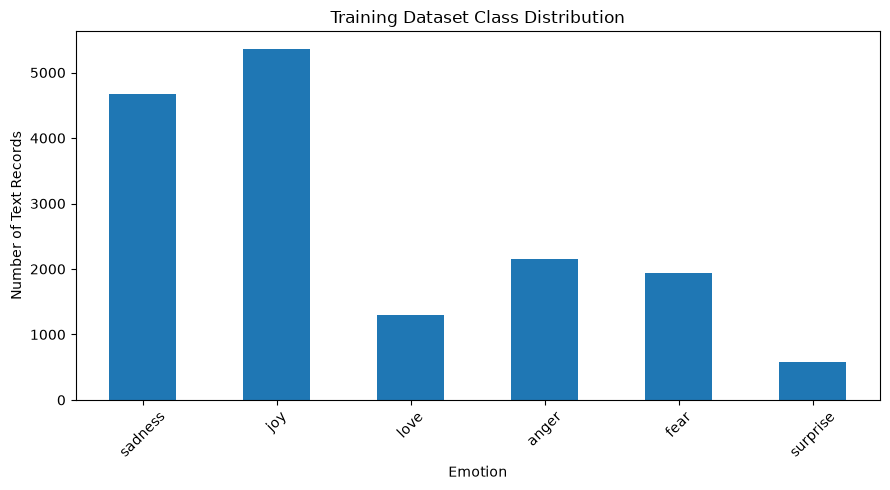

In [42]:
ax = train_distribution["count"].plot(
    kind="bar",
    figsize=(9, 5),
    title="Training Dataset Class Distribution",
)

ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Text Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
for dataframe in [train_df, validation_df, test_df]:
    dataframe["character_count"] = (
        dataframe["text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    dataframe["word_count"] = (
        dataframe["text"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

In [44]:
text_length_summary = train_df[
    ["character_count", "word_count"]
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

display(text_length_summary)

,character_count,word_count
count,16000.000000,16000.000000
mean,96.845812,19.166313
std,55.904953,10.986905
min,7.000000,2.000000
25%,53.000000,11.000000
50%,86.000000,17.000000
75%,129.000000,25.000000
90%,176.000000,35.000000
95%,207.050000,41.000000
99%,263.010000,52.000000


In [45]:
short_text_records = train_df[
    train_df["word_count"] <= 2
].sort_values("word_count")

print(
    "Records containing two words or fewer:",
    len(short_text_records)
)

display(
    short_text_records[
        ["text", "emotion", "word_count"]
    ].head(20)
)

Records containing two words or fewer: 8


,text,emotion,word_count
4150,earth crake,fear,2
4997,during lectures,joy,2
8824,in sweden,fear,2
9355,no response,anger,2
12204,one night,joy,2
12546,at school,anger,2
12801,one day,sadness,2
13316,no description,anger,2


In [46]:
long_text_threshold = train_df[
    "word_count"
].quantile(0.99)

long_text_records = train_df[
    train_df["word_count"] >= long_text_threshold
].sort_values(
    "word_count",
    ascending=False,
)

print(
    "99th percentile threshold:",
    long_text_threshold
)

print(
    "Long records:",
    len(long_text_records)
)

display(
    long_text_records[
        ["text", "emotion", "word_count"]
    ].head(10)
)

99th percentile threshold: 52.0
Long records: 181


,text,emotion,word_count
6322,i guess which meant or so i assume no photos n...,sadness,66
9618,i feel you i dont believ in you but i keep my ...,joy,64
9626,i feel in my bones like nobody cares if im her...,sadness,64
7222,i am happier this year in all ways i am just g...,joy,64
46,i lost my special mind but don t worry i m sti...,joy,64
11220,i confused my feelings with the truth because ...,love,63
14177,i like to add a slice of cheese and some peppe...,love,62
5373,i feel not offended in any form and should not...,anger,62
10390,i hope that those of you who actauly found thi...,joy,62
1542,i feel tat all of us in this world are clever ...,joy,62


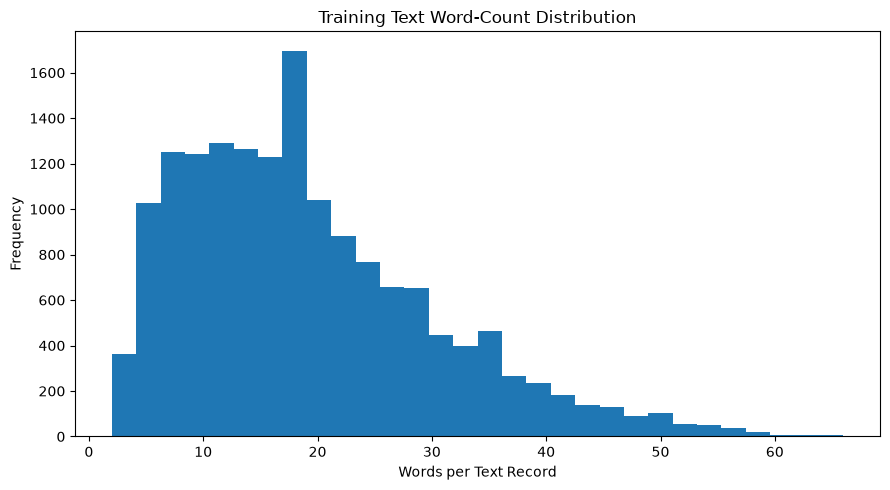

In [47]:
ax = train_df["word_count"].plot(
    kind="hist",
    bins=30,
    figsize=(9, 5),
    title="Training Text Word-Count Distribution",
)

ax.set_xlabel("Words per Text Record")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [48]:
sample_records = (
    train_df.groupby(
        "emotion",
        group_keys=False
    )
    .sample(
        n=3,
        random_state=42
    )
    [["emotion", "text"]]
    .sort_values("emotion")
)

display(sample_records)

,emotion,text
15428,anger,i ve been feeling a bit cranky with the kids t...
4989,anger,i feel frustrated sometimes with my mac lipsti...
15386,anger,i feeling stressed
15363,fear,im standing by myself off near maxs crib watch...
11517,fear,i have to admit i feel a little hesitant about...
7741,fear,i started feeling shaky hungry
3360,joy,i want to be in the future years some of you m...
14013,joy,i do not feel glamourous
15203,joy,i want you on the trip that i feel is cool
5083,love,i feel absolutely loved


In [49]:
data_quality_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test"
    ],

    "rows": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],

    "missing_text": [
        train_df["text"].isna().sum(),
        validation_df["text"].isna().sum(),
        test_df["text"].isna().sum(),
    ],

    "missing_labels": [
        train_df["label"].isna().sum(),
        validation_df["label"].isna().sum(),
        test_df["label"].isna().sum(),
    ],

    "empty_text": [
        train_df["text"].fillna("").str.strip().eq("").sum(),
        validation_df["text"].fillna("").str.strip().eq("").sum(),
        test_df["text"].fillna("").str.strip().eq("").sum(),
    ],

    "exact_duplicates": [
        train_df.duplicated(subset=["text", "label"]).sum(),
        validation_df.duplicated(subset=["text", "label"]).sum(),
        test_df.duplicated(subset=["text", "label"]).sum(),
    ],
})

display(data_quality_summary)

,split,rows,missing_text,missing_labels,empty_text,exact_duplicates
0,train,16000,0,0,0,1
1,validation,2000,0,0,0,0
2,test,2000,0,0,0,0


### Final Duplicate and Cross-Split Consistency Checks

Before cleaning, conflicting labels are examined within all dataset splits and
across training, validation, and test data. This ensures that duplicate removal
does not hide annotation inconsistencies.

In [50]:
validation_conflicts = find_conflicting_labels(validation_df)
test_conflicts = find_conflicting_labels(test_df)

print(
    "Training conflicting texts:",
    train_conflicts["text"].nunique()
)

print(
    "Validation conflicting texts:",
    validation_conflicts["text"].nunique()
)

print(
    "Test conflicting texts:",
    test_conflicts["text"].nunique()
)

Training conflicting texts: 30
Validation conflicting texts: 2
Test conflicting texts: 0


In [51]:
def inspect_overlap(text_values, first_df, second_df, first_name, second_name):
    overlap_records = pd.concat([
        first_df[first_df["text"].isin(text_values)].assign(split=first_name),
        second_df[second_df["text"].isin(text_values)].assign(split=second_name),
    ])

    return (
        overlap_records[
            ["text", "label", "emotion", "split"]
        ]
        .sort_values(["text", "split"])
    )


train_validation_records = inspect_overlap(
    train_validation_overlap,
    train_df,
    validation_df,
    "train",
    "validation",
)

train_test_records = inspect_overlap(
    train_test_overlap,
    train_df,
    test_df,
    "train",
    "test",
)

validation_test_records = inspect_overlap(
    validation_test_overlap,
    validation_df,
    test_df,
    "validation",
    "test",
)

print("TRAIN ↔ VALIDATION")
display(train_validation_records)

print("TRAIN ↔ TEST")
display(train_test_records)

print("VALIDATION ↔ TEST")
display(validation_test_records)

TRAIN ↔ VALIDATION


,text,label,emotion,split
556,i feel completely blessed to be a part of this...,2,love,train
1626,i feel completely blessed to be a part of this...,1,joy,validation
8135,i feel so blessed to be a part of your days,2,love,train
466,i feel so blessed to be a part of your days,1,joy,validation
2649,i feel that being faithful isnt enough in your...,1,joy,train
1672,i feel that being faithful isnt enough in your...,2,love,validation
2112,i honestly feel at heart we should be faithful...,1,joy,train
478,i honestly feel at heart we should be faithful...,2,love,validation
8258,i miss our talks our cuddling our kissing and ...,1,joy,train
60,i miss our talks our cuddling our kissing and ...,2,love,validation


TRAIN ↔ TEST


,text,label,emotion,split
502,i am feeling stressed and more than a bit anxious,3,anger,test
11898,i am feeling stressed and more than a bit anxious,0,sadness,train
353,i could feel his breath on me and smell the sw...,1,joy,test
15360,i could feel his breath on me and smell the sw...,2,love,train
959,i feel cared for and accepted,2,love,test
1793,i feel cared for and accepted,1,joy,train
1887,i feel like some of you have pains and you can...,1,joy,test
112,i feel like some of you have pains and you can...,2,love,train
265,i feel so blessed and honored that we get to b...,2,love,test
8996,i feel so blessed and honored that we get to b...,1,joy,train


VALIDATION ↔ TEST


,text,label,emotion,split
1826,i don t always feel like i have amazing style ...,1,joy,test
1230,i don t always feel like i have amazing style ...,5,surprise,validation
86,i feel like i am in paradise kissing those swe...,1,joy,test
1788,i feel like i am in paradise kissing those swe...,2,love,validation
575,i feel not having a generous spirit or a forgi...,2,love,test
879,i feel not having a generous spirit or a forgi...,1,joy,validation


## Dataset Cleaning

The initial data-quality assessment identified no missing values, empty text,
or invalid labels. However, duplicate and annotation consistency checks
identified several cases where identical text was assigned different emotion
labels.

Thirty text values had conflicting labels within the training split, two had
conflicting labels within validation, and cross-split comparisons also showed
identical text associated with different labels.

Because there is no objective basis for selecting one of the conflicting
annotations as correct, all occurrences of text associated with more than one
label are removed from the cleaned dataset.

Exact duplicate rows are also removed.

Following annotation cleaning, cross-split duplication is checked again to
prevent identical text from appearing in both model training and evaluation
data.

In [68]:
clean_train_df = train_df[["text", "label"]].copy()
clean_validation_df = validation_df[["text", "label"]].copy()
clean_test_df = test_df[["text", "label"]].copy()

print("Initial clean-copy sizes:")
print("Train:", clean_train_df.shape)
print("Validation:", clean_validation_df.shape)
print("Test:", clean_test_df.shape)

Initial clean-copy sizes:
Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)


In [69]:
combined_for_conflict_check = pd.concat(
    [
        clean_train_df.assign(split="train"),
        clean_validation_df.assign(split="validation"),
        clean_test_df.assign(split="test"),
    ],
    ignore_index=True,
)

global_label_counts = (
    combined_for_conflict_check
    .groupby("text")["label"]
    .nunique()
)

globally_conflicting_texts = set(
    global_label_counts[
        global_label_counts > 1
    ].index
)

print(
    "Unique text values with conflicting labels anywhere in the dataset:",
    len(globally_conflicting_texts)
)

Unique text values with conflicting labels anywhere in the dataset: 51


In [70]:
train_conflict_rows = clean_train_df[
    clean_train_df["text"].isin(globally_conflicting_texts)
]

validation_conflict_rows = clean_validation_df[
    clean_validation_df["text"].isin(globally_conflicting_texts)
]

test_conflict_rows = clean_test_df[
    clean_test_df["text"].isin(globally_conflicting_texts)
]

print("Rows affected by conflicting annotations:")
print("Train:", len(train_conflict_rows))
print("Validation:", len(validation_conflict_rows))
print("Test:", len(test_conflict_rows))

Rows affected by conflicting annotations:
Train: 76
Validation: 12
Test: 14


In [71]:
clean_train_df = clean_train_df[
    ~clean_train_df["text"].isin(globally_conflicting_texts)
].copy()

clean_validation_df = clean_validation_df[
    ~clean_validation_df["text"].isin(globally_conflicting_texts)
].copy()

clean_test_df = clean_test_df[
    ~clean_test_df["text"].isin(globally_conflicting_texts)
].copy()

print("Sizes after removing conflicting annotations:")
print("Train:", clean_train_df.shape)
print("Validation:", clean_validation_df.shape)
print("Test:", clean_test_df.shape)

Sizes after removing conflicting annotations:
Train: (15924, 2)
Validation: (1988, 2)
Test: (1986, 2)


In [72]:
before_train = len(clean_train_df)
before_validation = len(clean_validation_df)
before_test = len(clean_test_df)

clean_train_df = clean_train_df.drop_duplicates(
    subset=["text", "label"]
).copy()

clean_validation_df = clean_validation_df.drop_duplicates(
    subset=["text", "label"]
).copy()

clean_test_df = clean_test_df.drop_duplicates(
    subset=["text", "label"]
).copy()

print("Exact duplicates removed:")
print("Train:", before_train - len(clean_train_df))
print("Validation:", before_validation - len(clean_validation_df))
print("Test:", before_test - len(clean_test_df))

Exact duplicates removed:
Train: 1
Validation: 0
Test: 0


In [73]:
clean_train_df.reset_index(drop=True, inplace=True)
clean_validation_df.reset_index(drop=True, inplace=True)
clean_test_df.reset_index(drop=True, inplace=True)

In [75]:
clean_train_texts = set(clean_train_df["text"])
clean_validation_texts = set(clean_validation_df["text"])
clean_test_texts = set(clean_test_df["text"])

remaining_train_validation = (
    clean_train_texts & clean_validation_texts
)

remaining_train_test = (
    clean_train_texts & clean_test_texts
)

remaining_validation_test = (
    clean_validation_texts & clean_test_texts
)

print(
    "Remaining Train ↔ Validation overlap:",
    len(remaining_train_validation)
)

print(
    "Remaining Train ↔ Test overlap:",
    len(remaining_train_test)
)

print(
    "Remaining Validation ↔ Test overlap:",
    len(remaining_validation_test)
)

Remaining Train ↔ Validation overlap: 0
Remaining Train ↔ Test overlap: 0
Remaining Validation ↔ Test overlap: 0


In [76]:
for dataframe in [
    clean_train_df,
    clean_validation_df,
    clean_test_df,
]:
    dataframe["emotion"] = dataframe["label"].map(LABEL_NAMES)

In [77]:
display(clean_train_df.head())

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Post-Cleaning Validation

The cleaned dataset is re-evaluated to confirm that missing values,
invalid labels, exact duplicates, conflicting annotations, and cross-split
duplication have been removed successfully.

In [78]:
def validate_clean_split(name, dataframe):
    print(f"\n{name.upper()}")
    print("-" * 40)

    print("Rows:", len(dataframe))

    print(
        "Missing text:",
        dataframe["text"].isna().sum()
    )

    print(
        "Missing labels:",
        dataframe["label"].isna().sum()
    )

    print(
        "Empty text:",
        dataframe["text"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )

    print(
        "Invalid labels:",
        (~dataframe["label"].isin(VALID_LABELS)).sum()
    )

    print(
        "Exact duplicates:",
        dataframe.duplicated(
            subset=["text", "label"]
        ).sum()
    )


validate_clean_split("train", clean_train_df)
validate_clean_split(
    "validation",
    clean_validation_df
)
validate_clean_split("test", clean_test_df)


TRAIN
----------------------------------------
Rows: 15923
Missing text: 0
Missing labels: 0
Empty text: 0
Invalid labels: 0
Exact duplicates: 0

VALIDATION
----------------------------------------
Rows: 1988
Missing text: 0
Missing labels: 0
Empty text: 0
Invalid labels: 0
Exact duplicates: 0

TEST
----------------------------------------
Rows: 1986
Missing text: 0
Missing labels: 0
Empty text: 0
Invalid labels: 0
Exact duplicates: 0


In [79]:
clean_combined = pd.concat(
    [
        clean_train_df[["text", "label"]],
        clean_validation_df[["text", "label"]],
        clean_test_df[["text", "label"]],
    ],
    ignore_index=True,
)

remaining_conflicts = (
    clean_combined
    .groupby("text")["label"]
    .nunique()
)

remaining_conflicts = remaining_conflicts[
    remaining_conflicts > 1
]

print(
    "Remaining conflicting text values:",
    len(remaining_conflicts)
)

Remaining conflicting text values: 0


In [80]:
clean_train_texts = set(clean_train_df["text"])
clean_validation_texts = set(clean_validation_df["text"])
clean_test_texts = set(clean_test_df["text"])

print(
    "Train-validation:",
    len(clean_train_texts & clean_validation_texts)
)

print(
    "Train-test:",
    len(clean_train_texts & clean_test_texts)
)

print(
    "Validation-test:",
    len(clean_validation_texts & clean_test_texts)
)

Train-validation: 0
Train-test: 0
Validation-test: 0


In [81]:
cleaning_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test"
    ],

    "original_rows": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],

    "cleaned_rows": [
        len(clean_train_df),
        len(clean_validation_df),
        len(clean_test_df),
    ],
})

cleaning_summary["removed_rows"] = (
    cleaning_summary["original_rows"]
    - cleaning_summary["cleaned_rows"]
)

cleaning_summary["removed_percentage"] = (
    cleaning_summary["removed_rows"]
    / cleaning_summary["original_rows"]
    * 100
).round(2)

display(cleaning_summary)

,split,original_rows,cleaned_rows,removed_rows,removed_percentage
0,train,16000,15923,77,0.48
1,validation,2000,1988,12,0.60
2,test,2000,1986,14,0.70


In [82]:
clean_class_distribution = pd.DataFrame({
    "train": clean_train_df["emotion"].value_counts(),
    "validation": clean_validation_df["emotion"].value_counts(),
    "test": clean_test_df["emotion"].value_counts(),
}).reindex(LABEL_NAMES.values())

display(clean_class_distribution)

,train,validation,test
emotion,,,
sadness,4661,550,579
joy,5340,700,688
love,1283,173,156
anger,2152,274,274
fear,1923,211,224
surprise,564,80,65


In [83]:
clean_train_df[
    ["text", "label"]
].to_csv(
    PROCESSED_DATA_DIR / "emotion_train_clean.csv",
    index=False,
)

clean_validation_df[
    ["text", "label"]
].to_csv(
    PROCESSED_DATA_DIR / "emotion_validation_clean.csv",
    index=False,
)

clean_test_df[
    ["text", "label"]
].to_csv(
    PROCESSED_DATA_DIR / "emotion_test_clean.csv",
    index=False,
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [84]:
from pathlib import Path

processed_files = list(
    PROCESSED_DATA_DIR.glob("*.csv")
)

for file in processed_files:
    print(
        file.name,
        "-",
        round(file.stat().st_size / 1024, 2),
        "KB"
    )

emotion_test_clean.csv - 193.13 KB
emotion_train_clean.csv - 1553.71 KB
emotion_validation_clean.csv - 191.02 KB
